
HW3 - ENME485 - Merrick Summers - Shaft Health Assessment: Classifying Operation Modes with SVM

## Load the vibration data

Run this notebook from the `hw3` folder. Each text file contains one signal; its first five lines are a header. The test signals are loaded without using their answer labels.


In [151]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC


In [152]:
def load_signal(path):
    return np.loadtxt(path, skiprows=5)

healthy_files = sorted(Path("training-data/healthy").glob("*.txt"))
unbalance_1_files = sorted(Path("training-data/faulty/unbalance-1").glob("*.txt"))
unbalance_2_files = sorted(Path("training-data/faulty/unbalance-2").glob("*.txt"))
test_files = sorted(Path("testing-data").glob("*.txt"))

healthy_signals = [load_signal(path) for path in healthy_files]
unbalance_1_signals = [load_signal(path) for path in unbalance_1_files]
unbalance_2_signals = [load_signal(path) for path in unbalance_2_files]
test_signals = [load_signal(path) for path in test_files]

print("Training signals:", len(healthy_signals), "healthy,", len(unbalance_1_signals), "level 1,", len(unbalance_2_signals), "level 2")
print("Test signals:", len(test_signals))
print("Samples in first signal:", len(healthy_signals[0]))


Training signals: 20 healthy, 20 level 1, 20 level 2
Test signals: 30
Samples in first signal: 38400


## Example training signals

Show the first loaded signal from each class in the time and frequency domains. The sampling rate is 2,560 samples per second.


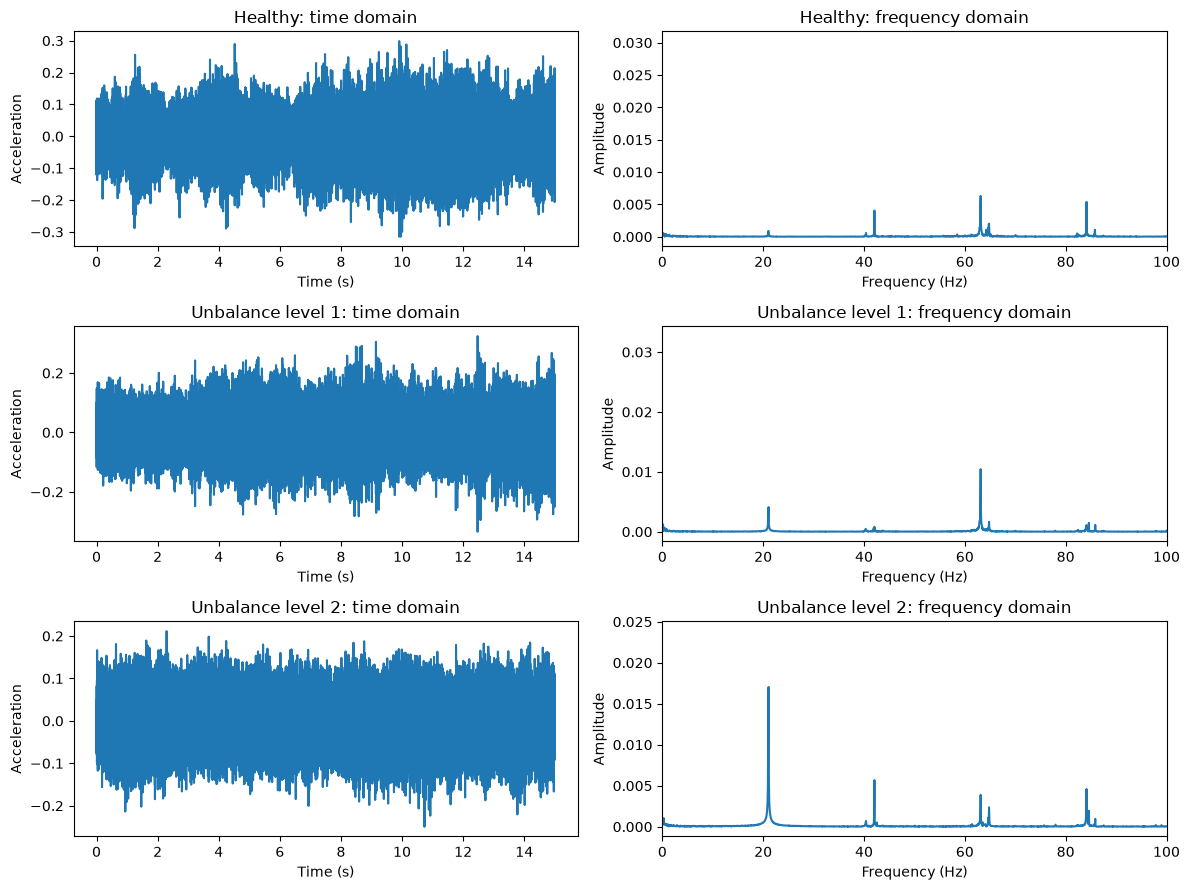

In [153]:
SAMPLING_RATE = 2560  # samples per second (Hz)

examples = [
    ("Healthy", healthy_signals[0]),
    ("Unbalance level 1", unbalance_1_signals[0]),
    ("Unbalance level 2", unbalance_2_signals[0]),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for row, (label, signal) in enumerate(examples):
    time = np.arange(len(signal)) / SAMPLING_RATE
    frequencies = rfftfreq(len(signal), d=1 / SAMPLING_RATE)
    amplitudes = 2 * np.abs(rfft(signal)) / len(signal)

    axes[row, 0].plot(time, signal)
    axes[row, 0].set_title(f"{label}: time domain")
    axes[row, 0].set_xlabel("Time (s)")
    axes[row, 0].set_ylabel("Acceleration")

    axes[row, 1].plot(frequencies, amplitudes)
    axes[row, 1].set_title(f"{label}: frequency domain")
    axes[row, 1].set_xlabel("Frequency (Hz)")
    axes[row, 1].set_ylabel("Amplitude")
    axes[row, 1].set_xlim(0, 100)

fig.tight_layout()
plt.show()


## Extract features

Use raw signals without filtering. The first six features describe the time-domain shape and size. The remaining features measure peaks near 1X–4X (20–80 Hz) and their ratios to RMS. The ±0.5 Hz windows allow slight peak shifts. Kurtosis is 3 for a normal distribution.


In [154]:
SHAFT_FREQUENCY = 20  # Hz; 1X shaft rotation
HARMONIC_HALF_WIDTH = 0.5  # Hz


def harmonic_peak(frequencies, amplitudes, center):
    in_band = (frequencies >= center - HARMONIC_HALF_WIDTH) & (frequencies <= center + HARMONIC_HALF_WIDTH)
    return amplitudes[in_band].max()


def extract_features(signal):
    rms = np.sqrt(np.mean(signal**2))
    frequencies = rfftfreq(len(signal), d=1 / SAMPLING_RATE)
    amplitudes = 2 * np.abs(rfft(signal)) / len(signal)

    features = {
        "RMS": rms,
        "Peak-to-peak": np.ptp(signal),
        "Standard deviation": np.std(signal),
        "Kurtosis": kurtosis(signal, fisher=False),
        "Skewness": skew(signal),
        "Crest factor": np.max(np.abs(signal)) / rms,
    }

    for harmonic in range(1, 5):
        peak = harmonic_peak(frequencies, amplitudes, harmonic * SHAFT_FREQUENCY)
        features[f"{harmonic}X amplitude"] = peak
        features[f"{harmonic}X amplitude / RMS"] = peak / rms

    return features


healthy_features = pd.DataFrame([extract_features(signal) for signal in healthy_signals])
unbalance_1_features = pd.DataFrame([extract_features(signal) for signal in unbalance_1_signals])
unbalance_2_features = pd.DataFrame([extract_features(signal) for signal in unbalance_2_signals])
test_features = pd.DataFrame([extract_features(signal) for signal in test_signals])

training_features = pd.concat(
    [healthy_features, unbalance_1_features, unbalance_2_features], ignore_index=True
)
# Class labels: 0 = healthy, 1 = unbalance level 1, 2 = unbalance level 2.
training_labels = ([0] * len(healthy_signals)
                   + [1] * len(unbalance_1_signals)
                   + [2] * len(unbalance_2_signals))

print("Training features:", training_features.shape)
print("Test features:", test_features.shape)
display(training_features.head())


Training features: (60, 14)
Test features: (30, 14)


,RMS,Peak-to-peak,Standard deviation,Kurtosis,Skewness,Crest factor,1X amplitude,1X amplitude / RMS,2X amplitude,2X amplitude / RMS,3X amplitude,3X amplitude / RMS,4X amplitude,4X amplitude / RMS
0,0.066409,0.613653,0.066409,3.587488,-0.121979,4.743422,0.000062,0.000936,0.000579,0.008716,0.000205,0.003091,0.000038,0.000577
1,0.092479,0.688554,0.092479,2.938551,-0.062677,3.865084,0.000069,0.000743,0.000502,0.005431,0.000206,0.002231,0.000049,0.000526
2,0.070198,0.634557,0.070198,3.317284,0.044630,4.938712,0.000064,0.000910,0.000678,0.009664,0.000136,0.001932,0.000055,0.000782
3,0.076684,0.691687,0.076684,3.576105,-0.264599,5.104268,0.000075,0.000978,0.000661,0.008623,0.000139,0.001813,0.000062,0.000811
4,0.073982,0.837318,0.073979,4.483103,-0.248775,6.537908,0.000094,0.001271,0.000728,0.009845,0.000183,0.002472,0.000058,0.000778


## Multiclass Fisher scores

For each original feature, compare the variation **between** the three class means with the variation **within** the classes. A larger score suggests that feature separates the training classes more clearly on its own. This is a univariate ranking: it does not account for combinations of features, and it is not a significance test. PCA, by comparison, uses variance without the class labels.


In [155]:
class_groups = list(training_features.groupby(training_labels))
overall_mean = training_features.mean()

between_class = sum(
    len(group) * (group.mean() - overall_mean) ** 2
    for _, group in class_groups
)
within_class = sum(
    ((group - group.mean()) ** 2).sum()
    for _, group in class_groups
)

fisher_scores = (between_class / within_class).sort_values(ascending=False)
fisher_table = fisher_scores.rename("Fisher score").to_frame()
display(fisher_table)


,Fisher score
1X amplitude,51.329290
1X amplitude / RMS,24.479591
2X amplitude,4.528073
2X amplitude / RMS,3.602787
3X amplitude,0.511013
RMS,0.229602
Standard deviation,0.229531
3X amplitude / RMS,0.117967
4X amplitude / RMS,0.090963
4X amplitude,0.067844


## Linear discriminant analysis

Standardize the original features using the training data, then use the known training labels to find two LDA components. With three classes, LDA can produce at most two components. Apply the fitted scaler and LDA transform to the test features without using their labels.


In [156]:
scaler = StandardScaler()
scaled_training_features = scaler.fit_transform(training_features)
scaled_test_features = scaler.transform(test_features)

lda = LinearDiscriminantAnalysis(n_components=2)
training_lda = lda.fit_transform(scaled_training_features, training_labels)
test_lda = lda.transform(scaled_test_features)

print("Training LDA shape:", training_lda.shape)
print("Test LDA shape:", test_lda.shape)


Training LDA shape: (60, 2)
Test LDA shape: (30, 2)


## Linear SVM predictions with LDA

Fit a linear SVM to the two LDA components and the known training labels. Predict each test signal without using its answer label. Class numbers are 0 = healthy, 1 = unbalance level 1, and 2 = unbalance level 2.


In [157]:
svm_model = SVC(kernel="linear", C=1.0)
svm_model.fit(training_lda, training_labels)

test_predictions = svm_model.predict(test_lda)
test_results = pd.DataFrame({
    "Test file": [path.name for path in test_files],
    "Predicted class": test_predictions,
})

display(test_results)
print("Predictions by class:")
print(test_results["Predicted class"].value_counts().sort_index())


,Test file,Predicted class
0,Data Mar-26-14 Time 1533-21.txt,0
1,Data Mar-26-14 Time 1534-22.txt,0
2,Data Mar-26-14 Time 1540-23.txt,0
3,Data Mar-26-14 Time 1540-24.txt,0
4,Data Mar-26-14 Time 1540-25.txt,0
5,Data Mar-26-14 Time 1543-26.txt,0
6,Data Mar-26-14 Time 1543-27.txt,0
7,Data Mar-26-14 Time 1543-28.txt,0
8,Data Mar-26-14 Time 1544-29.txt,0
9,Data Mar-26-14 Time 1544-30.txt,0


Predictions by class:
Predicted class
0    10
1    10
2    10
Name: count, dtype: int64


## Decision regions for four SVM kernels

Fit one illustrative SVC per kernel on the same two LDA components. These settings are examples, not tuned choices. Background colors show predicted classes; dots show known training classes. The evaluation below still uses the original linear SVM.


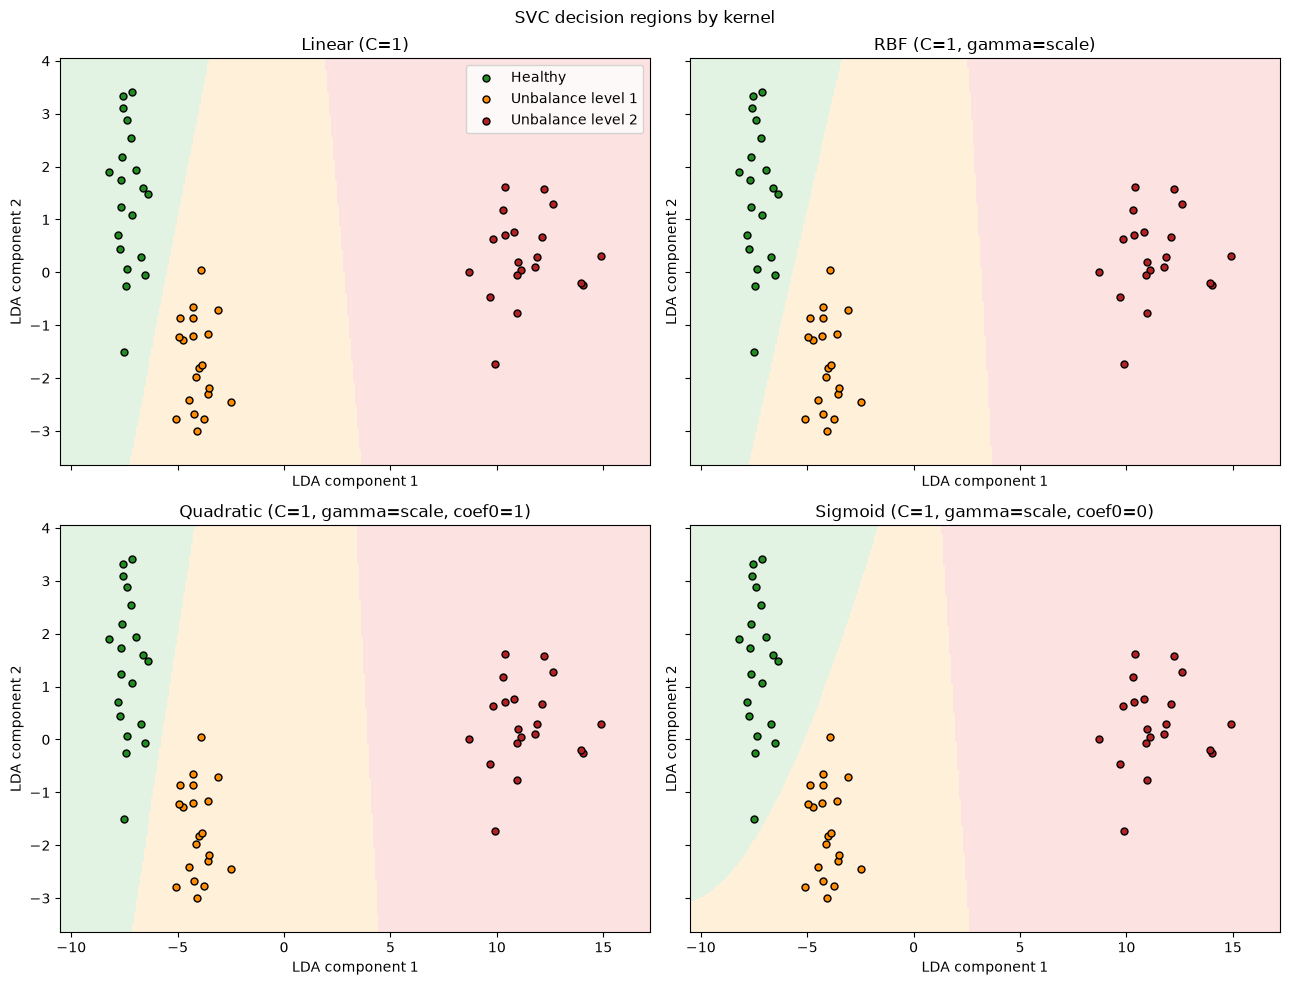

In [158]:
example_models = [
    ("Linear (C=1)", svm_model),
    ("RBF (C=1, gamma=scale)", SVC(kernel="rbf", C=1.0, gamma="scale")),
    ("Quadratic (C=1, gamma=scale, coef0=1)",
     SVC(kernel="poly", degree=2, C=1.0, gamma="scale", coef0=1.0)),
    ("Sigmoid (C=1, gamma=scale, coef0=0)",
     SVC(kernel="sigmoid", C=1.0, gamma="scale", coef0=0.0)),
]

x_min, x_max = training_lda[:, 0].min(), training_lda[:, 0].max()
y_min, y_max = training_lda[:, 1].min(), training_lda[:, 1].max()
x_padding = 0.1 * (x_max - x_min)
y_padding = 0.1 * (y_max - y_min)
x_grid, y_grid = np.meshgrid(
    np.linspace(x_min - x_padding, x_max + x_padding, 300),
    np.linspace(y_min - y_padding, y_max + y_padding, 300),
)
grid_points = np.column_stack((x_grid.ravel(), y_grid.ravel()))

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for ax, (title, model) in zip(axes.flat, example_models):
    if model is not svm_model:
        model.fit(training_lda, training_labels)
    grid_predictions = model.predict(grid_points).reshape(x_grid.shape)
    ax.contourf(x_grid, y_grid, grid_predictions,
                levels=[-0.5, 0.5, 1.5, 2.5],
                colors=["#e3f3e3", "#fff0d9", "#fde2e2"])

    for class_number, class_name, color in [
        (0, "Healthy", "forestgreen"),
        (1, "Unbalance level 1", "darkorange"),
        (2, "Unbalance level 2", "firebrick"),
    ]:
        in_class = np.array(training_labels) == class_number
        ax.scatter(training_lda[in_class, 0], training_lda[in_class, 1],
                   color=color, edgecolor="black", label=class_name, s=25)

    ax.set_title(title)
    ax.set_xlabel("LDA component 1")
    ax.set_ylabel("LDA component 2")

axes[0, 0].legend()
fig.suptitle("SVC decision regions by kernel")
fig.tight_layout()
plt.show()


## Five-fold hyperparameter searches

Use stratified five-fold cross-validation on the 60 training signals. Each candidate pipeline fits its own scaler, LDA, and SVC within each fold. The linear search tries nine logarithmically spaced `C` values from 1e-5 to 1e4, spanning nine orders of magnitude. The RBF search tries three `C` values times three `gamma` values. Accuracy is the validation score. The test labels are not involved in either search, and the final test assessment below still uses the original linear SVM.


In [159]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
linear_c_values = np.logspace(-5, 4, 9)  # 1e-5 to 1e4: nine orders of magnitude
rbf_c_values = [0.1, 1, 10]
rbf_gamma_values = [0.001, 0.01, 0.1]

linear_pipeline = make_pipeline(
    StandardScaler(), LinearDiscriminantAnalysis(n_components=2),
    SVC(kernel="linear")
)
linear_search = GridSearchCV(
    linear_pipeline, {"svc__C": linear_c_values}, cv=cv, scoring="accuracy"
)
linear_search.fit(training_features, training_labels)

linear_scores = pd.DataFrame({
    "C": linear_search.cv_results_["param_svc__C"],
    "Mean CV accuracy": linear_search.cv_results_["mean_test_score"],
})
print("Linear SVC: best C =", linear_search.best_params_["svc__C"])
print(f"Best mean CV accuracy: {linear_search.best_score_:.1%}")
display(linear_scores)

rbf_pipeline = make_pipeline(
    StandardScaler(), LinearDiscriminantAnalysis(n_components=2),
    SVC(kernel="rbf")
)
rbf_search = GridSearchCV(
    rbf_pipeline,
    {"svc__C": rbf_c_values, "svc__gamma": rbf_gamma_values},
    cv=cv, scoring="accuracy"
)
rbf_search.fit(training_features, training_labels)

rbf_scores = pd.DataFrame({
    "C": rbf_search.cv_results_["param_svc__C"],
    "gamma": rbf_search.cv_results_["param_svc__gamma"],
    "Mean CV accuracy": rbf_search.cv_results_["mean_test_score"],
}).sort_values("Mean CV accuracy", ascending=False)
print("RBF SVC: best settings =", rbf_search.best_params_)
print(f"Best mean CV accuracy: {rbf_search.best_score_:.1%}")
display(rbf_scores)


Linear SVC: best C = 0.023713737056616554
Best mean CV accuracy: 100.0%


,C,Mean CV accuracy
0,0.000010,0.983333
1,0.000133,0.983333
2,0.001778,0.983333
3,0.023714,1.000000
4,0.316228,1.000000
5,4.216965,1.000000
6,56.234133,1.000000
7,749.894209,1.000000
8,10000.000000,1.000000


RBF SVC: best settings = {'svc__C': 0.1, 'svc__gamma': 0.1}
Best mean CV accuracy: 100.0%


,C,gamma,Mean CV accuracy
2,0.1,0.100,1.000000
4,1.0,0.010,1.000000
5,1.0,0.100,1.000000
6,10.0,0.001,1.000000
7,10.0,0.010,1.000000
8,10.0,0.100,1.000000
0,0.1,0.001,0.983333
1,0.1,0.010,0.983333
3,1.0,0.001,0.983333


### Decision regions for the search candidates

Each panel is refitted on all 60 training signals for visualization. The percentage in its title is its separate five-fold validation accuracy from the search above. All panels use the same LDA coordinates and plot limits so their shapes can be compared.


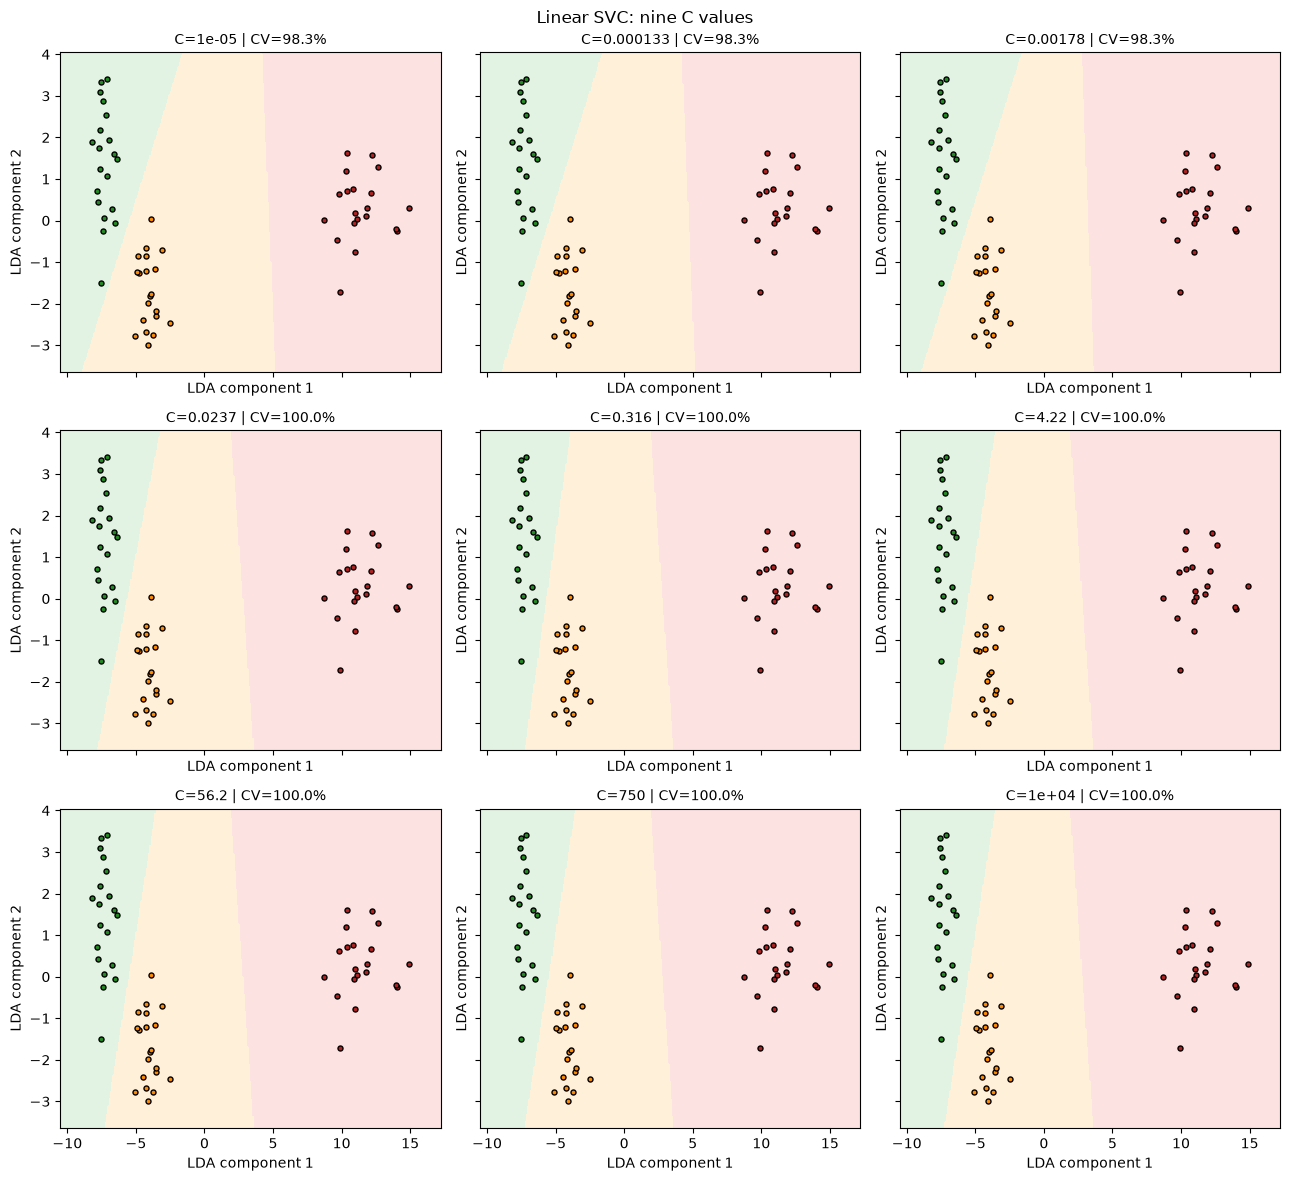

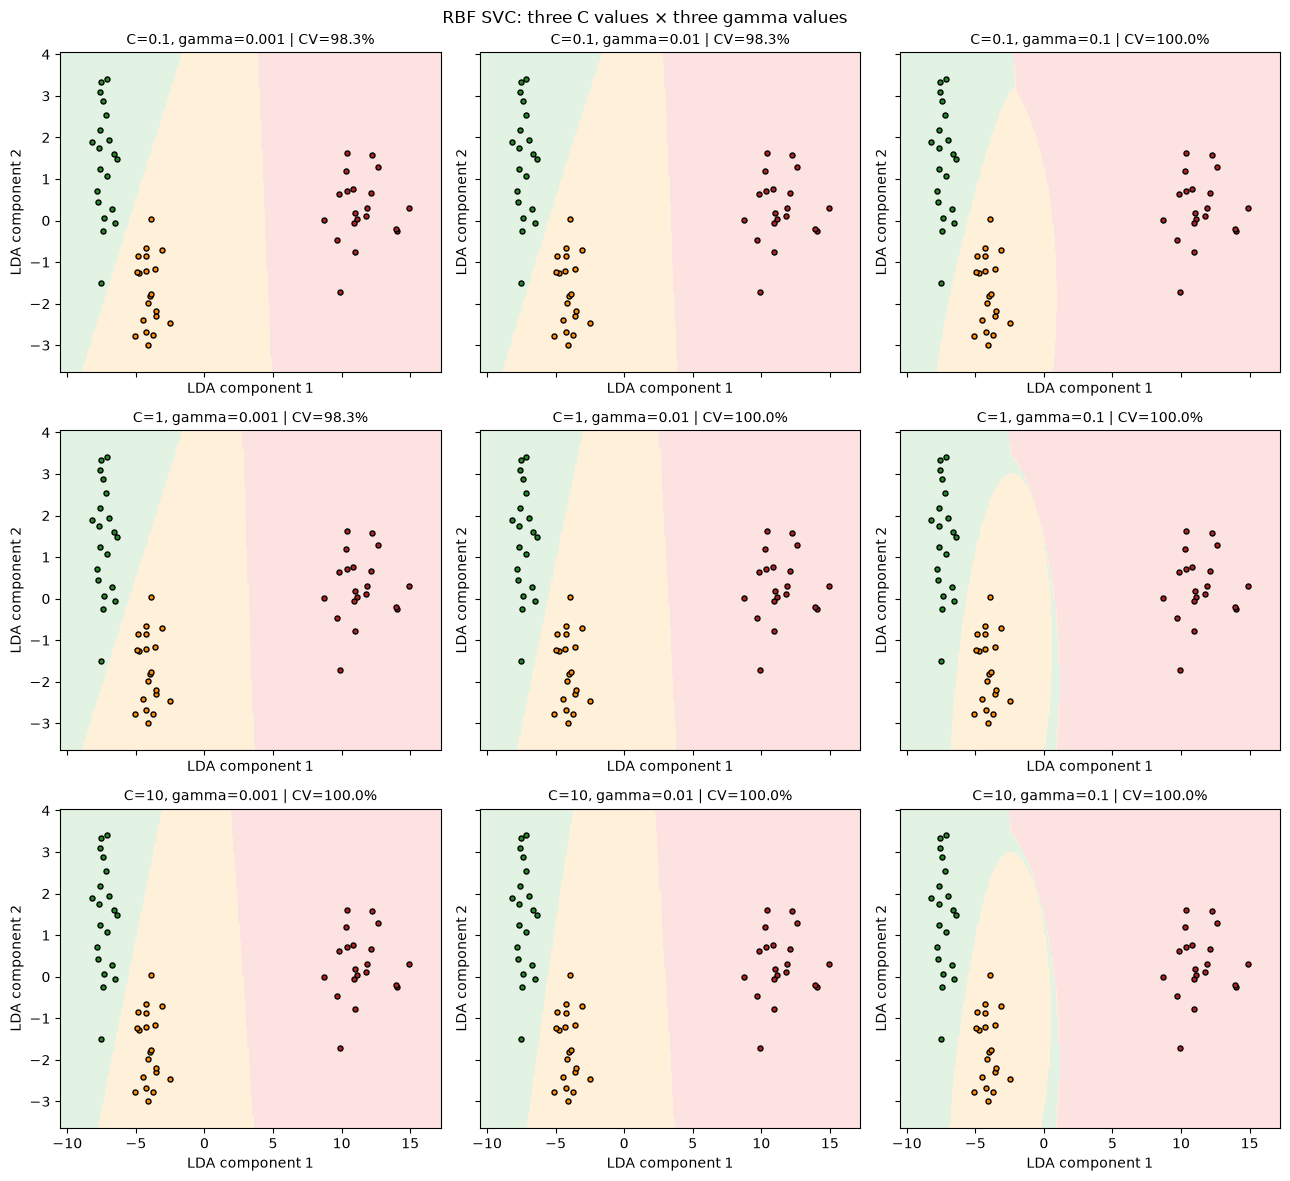

In [160]:
def plot_candidate(ax, model, title):
    regions = model.predict(grid_points).reshape(x_grid.shape)
    ax.contourf(x_grid, y_grid, regions,
                levels=[-0.5, 0.5, 1.5, 2.5],
                colors=["#e3f3e3", "#fff0d9", "#fde2e2"])
    for class_number, color in [(0, "forestgreen"), (1, "darkorange"), (2, "firebrick")]:
        in_class = np.array(training_labels) == class_number
        ax.scatter(training_lda[in_class, 0], training_lda[in_class, 1],
                   color=color, edgecolor="black", s=13)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("LDA component 1")
    ax.set_ylabel("LDA component 2")


fig, axes = plt.subplots(3, 3, figsize=(13, 12), sharex=True, sharey=True)
for ax, c, score in zip(axes.flat, linear_c_values,
                        linear_search.cv_results_["mean_test_score"]):
    model = SVC(kernel="linear", C=c).fit(training_lda, training_labels)
    plot_candidate(ax, model, f"C={c:.3g} | CV={score:.1%}")
fig.suptitle("Linear SVC: nine C values")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(13, 12), sharex=True, sharey=True)
rbf_cv_scores = rbf_search.cv_results_["mean_test_score"].reshape(3, 3)
for row, c in enumerate(rbf_c_values):
    for col, gamma in enumerate(rbf_gamma_values):
        model = SVC(kernel="rbf", C=c, gamma=gamma).fit(training_lda, training_labels)
        plot_candidate(axes[row, col], model,
                       f"C={c:g}, gamma={gamma:g} | CV={rbf_cv_scores[row, col]:.1%}")
fig.suptitle("RBF SVC: three C values × three gamma values")
fig.tight_layout()
plt.show()


## Final model decision regions

The selected model is the original linear `SVC(C=1)` fitted to the two LDA components. Background regions show predictions. Circles are labeled training signals; larger X markers are test signals colored by the model's predicted class. Test answer labels are not used in this plot. The plotting area includes both training and test signals.


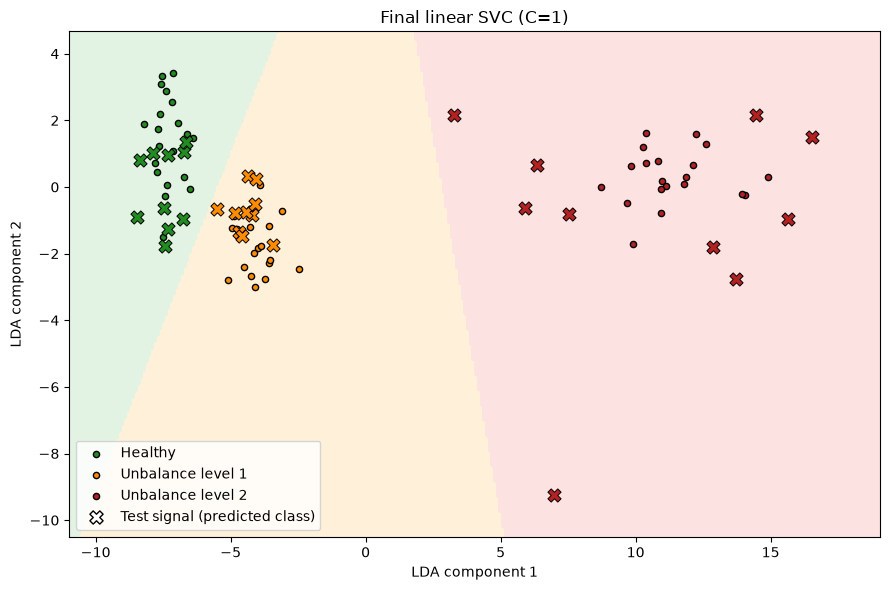

In [161]:
all_lda_points = np.vstack((training_lda, test_lda))
final_x_min, final_x_max = all_lda_points[:, 0].min(), all_lda_points[:, 0].max()
final_y_min, final_y_max = all_lda_points[:, 1].min(), all_lda_points[:, 1].max()
final_x_padding = 0.1 * (final_x_max - final_x_min)
final_y_padding = 0.1 * (final_y_max - final_y_min)
final_x_grid, final_y_grid = np.meshgrid(
    np.linspace(final_x_min - final_x_padding, final_x_max + final_x_padding, 300),
    np.linspace(final_y_min - final_y_padding, final_y_max + final_y_padding, 300),
)
final_grid_points = np.column_stack((final_x_grid.ravel(), final_y_grid.ravel()))
final_regions = svm_model.predict(final_grid_points).reshape(final_x_grid.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(final_x_grid, final_y_grid, final_regions,
            levels=[-0.5, 0.5, 1.5, 2.5],
            colors=["#e3f3e3", "#fff0d9", "#fde2e2"])
for class_number, class_name, color in [
    (0, "Healthy", "forestgreen"),
    (1, "Unbalance level 1", "darkorange"),
    (2, "Unbalance level 2", "firebrick"),
]:
    in_training_class = np.array(training_labels) == class_number
    in_test_class = test_predictions == class_number
    ax.scatter(training_lda[in_training_class, 0], training_lda[in_training_class, 1],
               color=color, edgecolor="black", s=20, label=class_name)
    ax.scatter(test_lda[in_test_class, 0], test_lda[in_test_class, 1],
               marker="X", s=90, color=color, edgecolor="black", linewidth=0.7)
ax.scatter([], [], marker="X", s=90, color="white", edgecolor="black",
           label="Test signal (predicted class)")
ax.set_title("Final linear SVC (C=1)")
ax.set_xlabel("LDA component 1")
ax.set_ylabel("LDA component 2")
ax.legend()
fig.tight_layout()
plt.show()


## Evaluate with the labels in the assignment

The PDF lists 10 healthy, 10 level 1, and 10 level 2 test signals. In `test_files`, the filenames sort into those same three consecutive groups. Assign those known labels only now, after making predictions. Rows in the confusion matrix are actual classes; columns are predicted classes.


Test accuracy: 100.0% (30/30 correct)


,Test file,Predicted class,Actual class
0,Data Mar-26-14 Time 1533-21.txt,0,0
1,Data Mar-26-14 Time 1534-22.txt,0,0
2,Data Mar-26-14 Time 1540-23.txt,0,0
3,Data Mar-26-14 Time 1540-24.txt,0,0
4,Data Mar-26-14 Time 1540-25.txt,0,0
5,Data Mar-26-14 Time 1543-26.txt,0,0
6,Data Mar-26-14 Time 1543-27.txt,0,0
7,Data Mar-26-14 Time 1543-28.txt,0,0
8,Data Mar-26-14 Time 1544-29.txt,0,0
9,Data Mar-26-14 Time 1544-30.txt,0,0


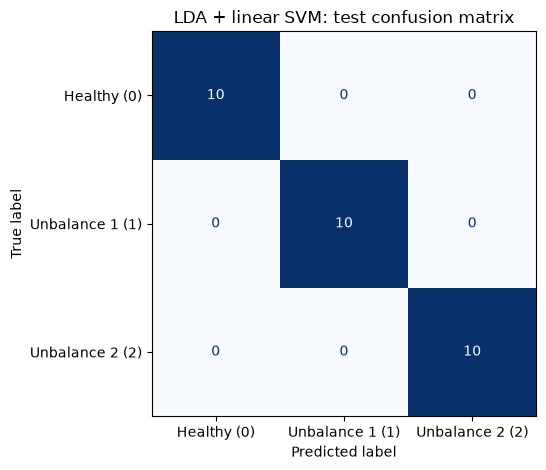

In [162]:
# The sorted test filenames appear in the PDF's class order: 10 healthy, 10 level 1, 10 level 2.
test_labels = np.array([0] * 10 + [1] * 10 + [2] * 10)
assert len(test_labels) == len(test_files)

test_results["Actual class"] = test_labels
confusion = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2])
accuracy = accuracy_score(test_labels, test_predictions)

print(f"Test accuracy: {accuracy:.1%} ({np.trace(confusion)}/{len(test_labels)} correct)")
display(test_results)

class_names = ["Healthy (0)", "Unbalance 1 (1)", "Unbalance 2 (2)"]
ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names).plot(
    cmap="Blues", colorbar=False
)
plt.title("LDA + linear SVM: test confusion matrix")
plt.tight_layout()
plt.show()
